In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_palette("deep")

In [2]:
df = pd.read_csv('player_data_for_clustering.csv')
print("Baseline Dataset Shape:", df.shape)
print("\nBaseline Dataset Head:")
print(df.head())

Baseline Dataset Shape: (460, 19)

Baseline Dataset Head:
  Player_ID              Player           Team Position  Gls_per90  \
0  42fd9c7f       Kylian Mbappé    Real Madrid       FW   0.959752   
1  e342ad68       Mohamed Salah      Liverpool       FW   0.773333   
2  8d78e732  Robert Lewandowski      Barcelona       FW   0.912162   
3  21a66f6a          Harry Kane  Bayern Munich       FW   0.981132   
4  e7695e6c       Mateo Retegui       Atalanta       FW   0.943396   

   OffensiveImpact  Won_per90  Lost_per90  AerialEff  AerialImpact  Tkl_per90  \
0         1.052632   0.123839    0.185759  40.000000      0.049536   0.247678   
1         1.253333   0.240000    0.373333  39.130435      0.093913   0.560000   
2         0.979730   1.250000    1.317568  48.684211      0.608553   0.337838   
3         1.320755   1.094340    0.754717  59.183673      0.647670   0.490566   
4         1.245283   1.924528    2.566038  42.857143      0.824798   0.528302   

   TklW_per90  DefImpact  Pass_Att

In [3]:
features = ['Gls_per90', 'OffensiveImpact', 'Won_per90', 'Lost_per90', 'AerialEff',
            'AerialImpact', 'Tkl_per90', 'TklW_per90', 'DefImpact', 'Pass_Att_per90',
            'Pass_Cmp_per90', 'PassImpact', 'Takeons_Att_per90', 'Takeons_Succ_per90',
            'TakeonImpact']

scaler = StandardScaler()
X = scaler.fit_transform(df[features])

print("\nStandardized Feature Shape:", X.shape)
print("\nSample of Standardized Features:")
print(pd.DataFrame(X, columns=features).head())


Standardized Feature Shape: (460, 15)

Sample of Standardized Features:
   Gls_per90  OffensiveImpact  Won_per90  Lost_per90  AerialEff  AerialImpact  \
0   3.264887         2.465333  -0.868127   -1.238720   0.129229     -0.698000   
1   2.358066         3.277671  -0.779769   -1.086545   0.060906     -0.639448   
2   3.033388         2.170264  -0.011513   -0.320510   0.811558      0.039570   
3   3.368887         3.550558  -0.129916   -0.777138   1.636513      0.091182   
4   3.185324         3.245087   0.501567    0.692344   0.353718      0.324885   

   Tkl_per90  TklW_per90  DefImpact  Pass_Att_per90  Pass_Cmp_per90  \
0  -1.463729   -1.398146  -1.298586        0.372316        0.614567   
1  -0.988155   -1.061253  -0.817871        0.221797        0.064248   
2  -1.326442   -1.363808  -1.092765       -1.143476       -1.002865   
3  -1.093882   -0.765150  -0.817573       -0.572985       -0.386220   
4  -1.036422   -0.948685  -1.151102       -0.797753       -0.642364   

   PassImpact

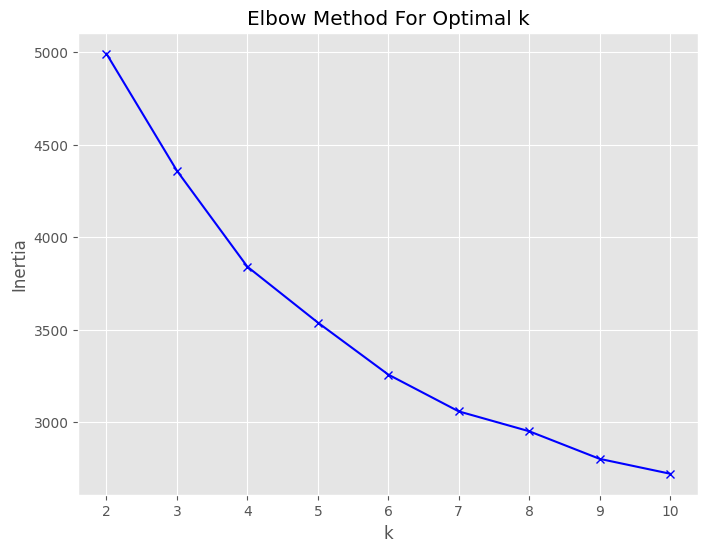


Inertia values for k=2 to 10: [4991.712424658259, 4359.1774576193875, 3840.2203868476086, 3538.16676207336, 3256.8283047853392, 3057.8490326296815, 2950.4020506222228, 2801.166770959414, 2720.7735154631464]


In [4]:
inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K, inertia, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

print("\nInertia values for k=2 to 10:", inertia)

In [5]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(X)

silhouette_avg = silhouette_score(X, cluster_labels)
print(f"\nSilhouette Score for k={k}: {silhouette_avg:.3f}")

df['Cluster'] = cluster_labels
print("\nSample of Players with Cluster Assignments:")
print(df[['Player_ID', 'Player', 'Cluster']].head(10))


Silhouette Score for k=4: 0.174

Sample of Players with Cluster Assignments:
  Player_ID              Player  Cluster
0  42fd9c7f       Kylian Mbappé        3
1  e342ad68       Mohamed Salah        0
2  8d78e732  Robert Lewandowski        2
3  21a66f6a          Harry Kane        0
4  e7695e6c       Mateo Retegui        2
5  8e92be30      Alexander Isak        0
6  0e0102eb       Omar Marmoush        3
7  1f44ac21      Erling Haaland        2
8  58eee997     Mason Greenwood        3
9  5d4f7d61       Patrik Schick        2


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


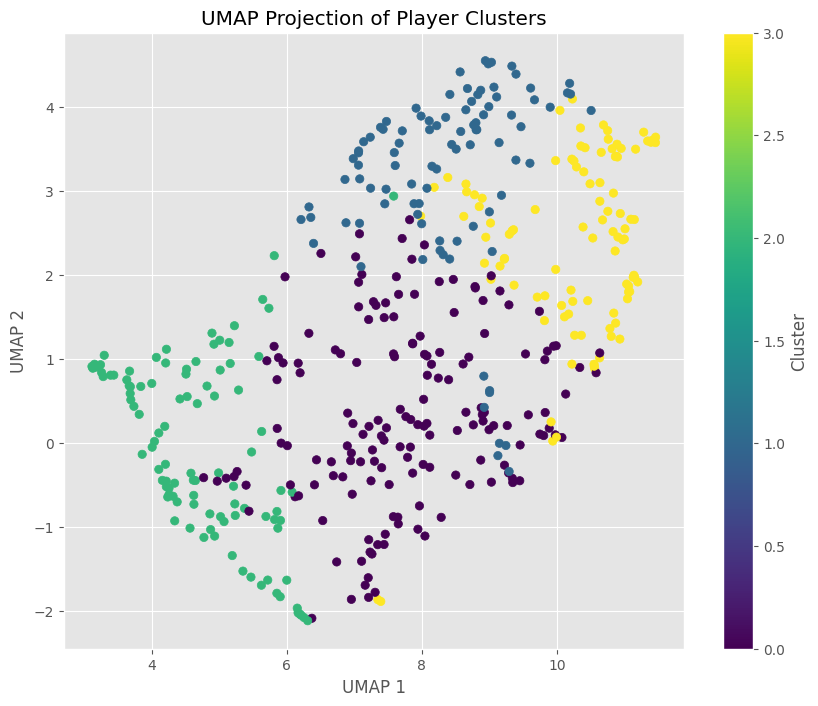


UMAP embedding shape: (460, 2)


In [6]:
reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(X)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=cluster_labels, cmap='viridis')
plt.colorbar(scatter, label='Cluster')
plt.title('UMAP Projection of Player Clusters')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

print("\nUMAP embedding shape:", embedding.shape)


Similar Players to Kylian Mbappé (Player_ID: 42fd9c7f):
    Player_ID           Player            Team Position  Cluster  Distance
430  fe012aca     Jeremie Boga            Nice     MFFW        3  3.755901
251  0174ba21       Robin Hack        Gladbach     FWMF        0  4.705751
218  16aa3654    Takefusa Kubo   Real Sociedad     MFFW        3  4.982245
337  cb64672e      Paul Wanner      Heidenheim     MFFW        1  5.177794
255  30144daa  Stephy Mavididi  Leicester City       FW        3  5.237464


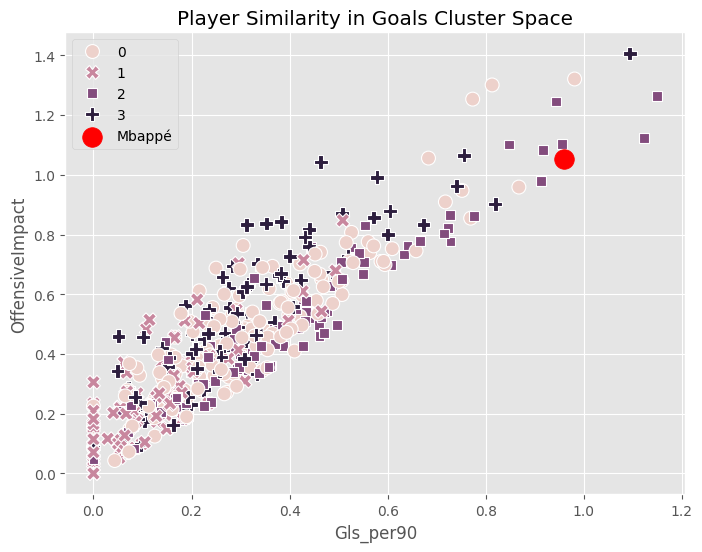

In [7]:
from scipy.spatial import distance_matrix

def find_similar_players(player_id, df, features, n_similar=5):
    player_data = df[df['Player_ID'] == player_id][features].values
    if len(player_data) == 0:
        return "Player not found"

    distances = distance_matrix(player_data, df[features].values)[0]
    similar_indices = distances.argsort()[1:n_similar + 1]
    similar_players = df.iloc[similar_indices][['Player_ID', 'Player', 'Team', 'Position', 'Cluster']]
    return similar_players.assign(Distance=distances[similar_indices])

player_id = '42fd9c7f'
similar_players = find_similar_players(player_id, df, features)
print(f"\nSimilar Players to {df[df['Player_ID'] == player_id]['Player'].values[0]} (Player_ID: {player_id}):")
print(similar_players)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Gls_per90', y='OffensiveImpact', hue='Cluster', style='Cluster', s=100)
plt.scatter(df[df['Player_ID'] == player_id]['Gls_per90'], df[df['Player_ID'] == player_id]['OffensiveImpact'],
            color='red', s=200, label='Mbappé')
plt.legend()
plt.title('Player Similarity in Goals Cluster Space')
plt.show()